# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**






----

# Encodings

**ANTES DE LLEGAR ACA TENGO QUE HABER TRABAJADO CON MIS DATOS FALTANTES!!!**

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [ ]:
import matplotlib.pyplot as plt
import numpy
import pandas

import seaborn
seaborn.set_context('talk')

In [ ]:
import plotly

In [ ]:
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Codificando valores no numéricos

Hasta este momento hemos realizado análisis de datos sobre distintos tipos de variables aleatorias. Sin embargo, muchos métodos utilizados para *Aprendizaje Automático* pueden ser aplicados solamente a matrices numéricas.

Por ello, antes de comenzar con cualquier tipo de modelado, tenemos que **codificar** (encode) toda la información categórica utilizando unicamente información numérica. Al realizar este proceso tenemos que tener en cuenta algunas propiedades que tendrán nuestros datos codificados, y cómo impactarán en los modelos.

### One-hot encodings

La forma más simple de realizar esta codificación de valores categóricos es construir un vector One-Hot encoding. Opera de la siguiente manera:

1. Se identifica el conjunto $C$ de categorías posibles de la variable aleatoria y la cantida de categorías $N = |C|$
2. Se asigna un número entero a cada categoría en el rango $[0; N)$.
3. Para cada valor $r_i$ de nuestro conjunto de datos con categoría $c_j$:

  1. Se construye un vector $x_i$ de 0s de tamaño $N$.
  2. Se asigna el valor 1 al vector $x_i$ en la posición de la categoría $c_j$.

Comenzaremos a trabajar con la librería scikit-learn, que dispone de la mayoría de funciones necesarias para pre-procesar un conjunto de datos y cuenta con tutoriales que explican las distintas opciones. Les recomendamos la sección de [Encoding Categorical Features](https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features).

Utilizaremos la clase *OneHotEncoder* para realizar la codificación. Todos los transformadores de scikit-learn siguen una misma interfaz en dos etapas: `fit` y `transform`.
* El método `fit` (entrenar) es el encargado de recopilar toda la información necesaria para aplicar el encoding. En este caso, implementa los pasos 1 y 2 del algoritmo anterior.
* El método `transform` es el que efectivamente construye los encoding para cada fila del conjunto de datos.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoder.fit(melb_df[['Type']])
# We can inspect the categories found by the encoder
encoder.categories_

[array(['h', 't', 'u'], dtype=object)]

In [ ]:
encoded_types = encoder.transform(melb_df[['Type']])
encoded_types[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

Esta transformación es tan común que Scikit-lean implementa el transformador `DictVectorizer` que codifican automáticamente todos las columnas categóricas y los combinan con los datos numéricos existentes.

Para poder utilizarlo, tendremos que convertir el conjunto de datos en una lista de diccionarios.


In [ ]:
feature_cols = ['Suburb', 'Type', 'Distance', 'Bedroom2', 'Bathroom',
            'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Regionname']
feature_dict = list(melb_df[feature_cols].T.to_dict().values())
feature_dict[:2]

[{'Suburb': 'Abbotsford',
  'Type': 'h',
  'Distance': 2.5,
  'Bedroom2': 2.0,
  'Bathroom': 1.0,
  'Car': 1.0,
  'Landsize': 202.0,
  'BuildingArea': nan,
  'YearBuilt': nan,
  'Regionname': 'Northern Metropolitan'},
 {'Suburb': 'Abbotsford',
  'Type': 'h',
  'Distance': 2.5,
  'Bedroom2': 2.0,
  'Bathroom': 1.0,
  'Car': 0.0,
  'Landsize': 156.0,
  'BuildingArea': 79.0,
  'YearBuilt': 1900.0,
  'Regionname': 'Northern Metropolitan'}]

In [ ]:
from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer()
feature_matrix = vec.fit_transform(feature_dict)


In [ ]:
feature_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 135800 stored elements and shape (13580, 332)>

In [ ]:
vec.get_feature_names_out()[:10]

array(['Bathroom', 'Bedroom2', 'BuildingArea', 'Car', 'Distance',
       'Landsize', 'Regionname=Eastern Metropolitan',
       'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan',
       'Regionname=Northern Victoria'], dtype=object)

## Matrices esparsas

Las codificaciones one-hot tienen la propiedad de aumentar la cantidad de memoria requerida para almacenar una variable de manera **cuadrática** con respecto al número de categorías. Sin embargo, la mayoría de los elementos de la nueva representación serán nulos. La cantidad de elementos no-nulos de la matriz crece **linealmente** con respecto al número de categorías a representar.

Por ello existen las *matrices esparsas*, que almacenan unicamente los valores no-nulos de una matriz en distintas estructuras de datos.

Los métodos de codificación como `DictVectorizer` o `OneHotEncoding` suelen devolver como resultado matrices esparsas si es más eficiente en términos de recursos computacionales.

![picture](https://matteding.github.io/images/coo.gif)

Existen [distintos tipos de matrices esparsas](https://docs.scipy.org/doc/scipy/reference/sparse.html) y las operaciones sobre cada una de ellas son distintas; y distintas a las matrices densas.

In [ ]:
# Fill nan values on sparse matrix.
if numpy.any(numpy.isnan(feature_matrix.data)):
  feature_matrix.data = numpy.nan_to_num(feature_matrix.data)

Para aplicar algunas transformaciones o modelos es necesario convertir las matrices esparsas a densas. Antes de realizar este cambio, es recomendable calcular el tamaño de la matriz final. Recordar que cada número de punto flotante ocupa 4 bytes para la precisión simple (numpy.float32) y 8 bytes para la precisión doble (numpy.float64).

In [ ]:
# Before doing this type of conversion, it's mandatory to calculate the
# size of the resulting matrix!
matrix_size_mb = feature_matrix.shape[0] * feature_matrix.shape[1] * 4 / 1024 / 1024
print("The dense matrix will weight approximately {:.2f} MB".format(matrix_size_mb))

limit_size_mb = 10
precision_type = numpy.float32
if matrix_size_mb < limit_size_mb:  # Matrix is less than 10MB
  dense_feature_matrix = feature_matrix.astype(precision_type).todense()
else:
  # We calculate how many rows would fit given the number of columns
  n_rows = int(limit_size_mb *1024 * 1024 / 4 / feature_matrix.shape[1])
  print("Matrix too big! Using only first {} of {} rows".format(
      n_rows, feature_matrix.shape[0]))
  dense_feature_matrix = feature_matrix[:n_rows].astype(precision_type).todense()

print("Final size: {:.2f}".format(dense_feature_matrix.nbytes / 1024 / 1024))

The dense matrix will weight approximately 17.20 MB
Matrix too big! Using only first 7895 of 13580 rows
Final size: 10.00


In [ ]:
# Remember to cut your original data as well.
if dense_feature_matrix.shape[0] < len(melb_df):
  melb_df_sample = melb_df.iloc[:dense_feature_matrix.shape[0]]
else:
  melb_df_sample = melb_df

## Reducción de dimensionalidad con PCA

En las siguientes filas, aplicaremos [PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca) para reducir la dimensionalidad del conjunto de datos a 2 dimensiones. Se seguirá un proceso similar al visto en la notebook de juguete.

In [ ]:
dense_feature_matrix.shape

(7895, 332)

In [ ]:
dense_feature_matrix_new = numpy.asarray(dense_feature_matrix)
dense_feature_matrix_new.shape

(7895, 332)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
dense_feature_matrix
scaled_dense_feature_matrix = scaler.fit_transform(dense_feature_matrix_new)
numpy.max(scaled_dense_feature_matrix), numpy.min(scaled_dense_feature_matrix)

(np.float32(1.0), np.float32(-1.0))

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=15)
pca.fit(scaled_dense_feature_matrix)
proyected_features = pca.transform(scaled_dense_feature_matrix)
proyected_features.shape

(7895, 15)

In [ ]:
pca.explained_variance_ratio_

array([0.1717449 , 0.13777278, 0.10051959, 0.08688609, 0.0476763 ,
       0.0418744 , 0.0246677 , 0.0105925 , 0.00950335, 0.00888173,
       0.00809332, 0.00783134, 0.00770825, 0.00717405, 0.00693008],
      dtype=float32)

In [ ]:
melb_df_sample.loc[:,['pca1_scaled', 'pca2_scaled']] = proyected_features[:,:2]

<Axes: ylabel='Price'>

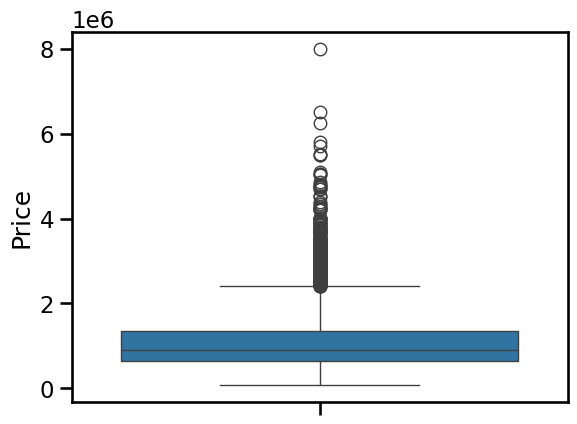

In [ ]:
seaborn.boxplot(melb_df_sample.Price)

<Axes: xlabel='pca1_scaled', ylabel='pca2_scaled'>

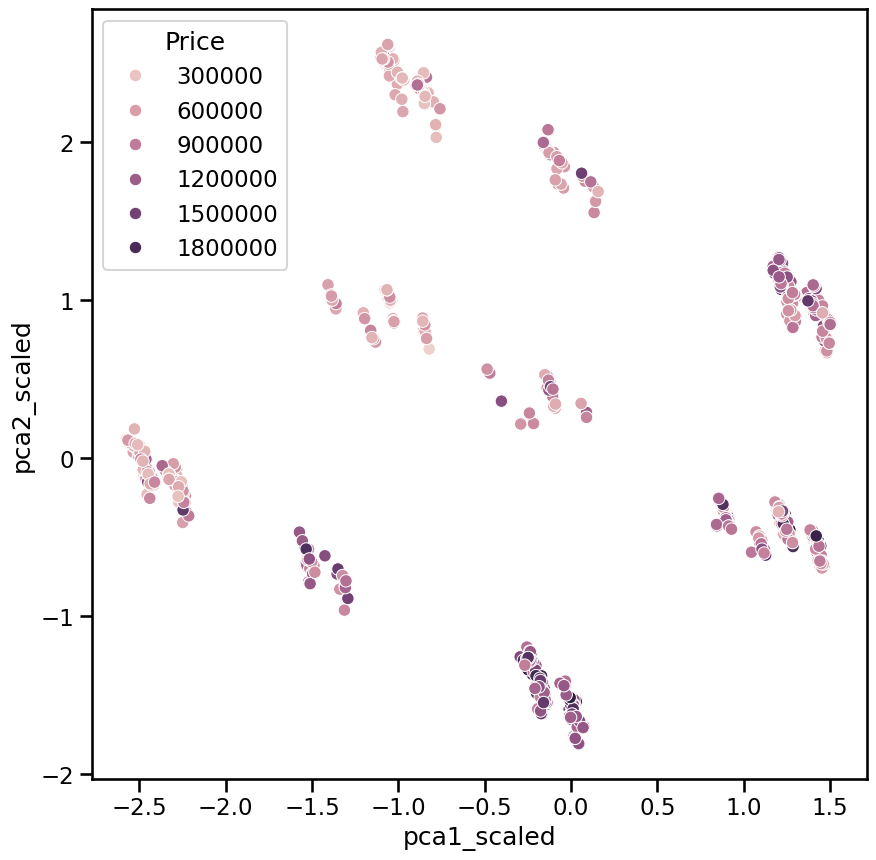

In [ ]:
data = melb_df_sample[melb_df_sample.Price < 2000000].sample(1000)
fig = plt.figure(figsize=(10, 10))
seaborn.scatterplot(data=data, x='pca1_scaled', y='pca2_scaled',
                    hue='Price')  # 'Landsize' 'Price' 'YearBuilt'

Tenemos que volver a escalar todos los datos a un mismo rango. ¿Utilizamos estandarización o escalado linear?

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
stdandard_dense_feature_matrix = std_scaler.fit_transform(dense_feature_matrix_new)
numpy.max(stdandard_dense_feature_matrix), numpy.min(stdandard_dense_feature_matrix)

(np.float32(88.84818), np.float32(-2.892464))

In [ ]:
from sklearn.decomposition import PCA
pca_std = PCA(n_components=15)
pca_std.fit(stdandard_dense_feature_matrix)
proyected_features_std = pca.transform(stdandard_dense_feature_matrix)
proyected_features_std.shape

(7895, 15)

In [ ]:
stdandard_dense_feature_matrix.shape

(7895, 332)

In [ ]:
pca_std.components_[0,:]

array([ 2.7975309e-01,  3.9959657e-01,  1.6522345e-01,  2.9984966e-01,
        3.4895399e-01,  6.9563486e-02,  1.5279384e-01,  8.6736174e-19,
       -2.1301897e-01, -2.7105054e-20,  5.8501273e-02, -1.3365368e-02,
        1.4588298e-01, -2.6469780e-23, -3.7163507e-02,  1.8409710e-02,
        3.0793719e-02,  1.6155871e-27, -1.9163959e-02,  1.6142564e-02,
       -1.3884211e-02,  2.5213834e-02, -0.0000000e+00,  3.8169388e-02,
       -0.0000000e+00, -3.1876717e-02,  1.3501180e-02,  3.7501853e-02,
        1.5983732e-02, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
        4.1181568e-02, -0.0000000e+00, -2.7562376e-02,  3.4006707e-02,
        5.7974558e-02, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00,  1.1725900e-02,  4.1500270e-02,
        5.5589166e-02, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00, -0.0000000e+00, -0.0000000e+00, -0.0000000e+00,
        3.2361321e-02,  2.7565451e-02, -0.0000000e+00,  3.2190152e-02,
      

In [ ]:
pca_std.explained_variance_ratio_

array([0.02208811, 0.0172487 , 0.01447893, 0.01342922, 0.01286661,
       0.01064775, 0.0099965 , 0.0081892 , 0.00774077, 0.00702141,
       0.00681291, 0.00658215, 0.00655205, 0.00652474, 0.00651908],
      dtype=float32)

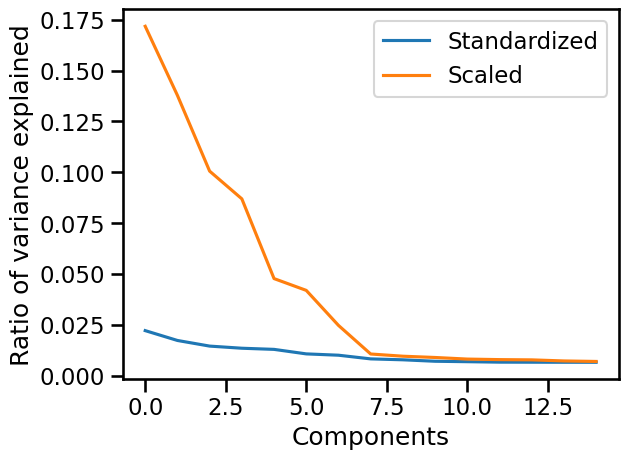

In [ ]:
seaborn.lineplot(x=range(pca_std.n_components),
                 y=pca_std.explained_variance_ratio_, label='Standardized')
seaborn.lineplot(x=range(pca.n_components),
                 y=pca.explained_variance_ratio_, label='Scaled')
plt.ylabel("Ratio of variance explained")
plt.xlabel("Components")
plt.legend()

In [ ]:
melb_df_sample.loc[:,['pca1_standard', 'pca2_standard']] = proyected_features_std[:,:2]

<Axes: xlabel='pca1_standard', ylabel='pca2_standard'>

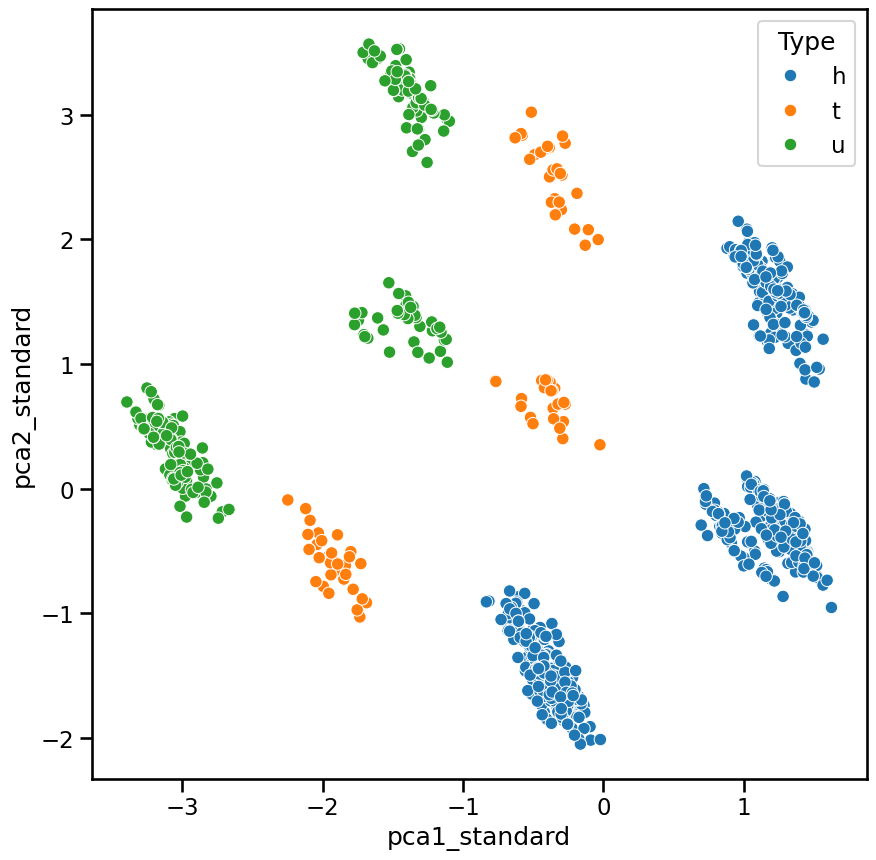

In [ ]:
data = melb_df_sample.sample(1000)
fig = plt.figure(figsize=(10, 10))
seaborn.scatterplot(data=data, x='pca1_standard', y='pca2_standard',
                    hue='Type')  # 'Landsize' 'Price' 'YearBuilt'